In [638]:
from pathlib import Path
import numpy as np
import pandas as pd

In [639]:
DATA_DIR = Path.cwd().resolve().parent / "data"

df_data = pd.read_parquet(DATA_DIR / "02_data_ataques_cardiacos_transformados.parquet")

In [640]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1319 non-null   float64
 1   gender        1319 non-null   int64  
 2   heart_rate    1319 non-null   float64
 3   systolic_bp   1319 non-null   float64
 4   diastolic_bp  1319 non-null   float64
 5   blood_sugar   1319 non-null   float64
 6   ckmb          1319 non-null   float64
 7   troponin      1319 non-null   float64
 8   result        1319 non-null   bool   
 9   result_num    1319 non-null   int32  
dtypes: bool(1), float64(7), int32(1), int64(1)
memory usage: 89.0 KB


In [641]:
cols_categorics = ['gender']
cols_numerics = ['age','heart_rate','systolic_bp','diastolic_bp','blood_sugar','ckmb','troponin']

## Herramientas de Pre-procesamiento

In [642]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

### Pipelines e imputacion

In [643]:
cols_numerics_pipeline = Pipeline(steps =[
    ('imputer', SimpleImputer(strategy = 'median')) 
])

cols_numeric_pipeline_mean = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())  
])

cols_categorics_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [644]:
preprocessor_median = ColumnTransformer(transformers=[
    ('num', cols_numerics_pipeline, cols_numerics),
    ('cat',cols_categorics_pipeline, cols_categorics)
])

preprocessor_median

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['age', 'heart_rate', 'systolic_bp',
                                  'diastolic_bp', 'blood_sugar', 'ckmb',
                                  'troponin']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender'])])

In [645]:
preprocessor_mean = ColumnTransformer(transformers=[
    ('num', cols_numeric_pipeline_mean, cols_numerics),
    ('cat',cols_categorics_pipeline, cols_categorics)
])

preprocessor_mean

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'heart_rate', 'systolic_bp',
                                  'diastolic_bp', 'blood_sugar', 'ckmb',
                                  'troponin']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender'])])

### Train / Test

In [646]:
from sklearn.model_selection import train_test_split

In [647]:
X_feature = df_data.drop(columns=['result'])
y_target = df_data['result']

X_train , X_test, y_train, y_test = train_test_split(
    X_feature,
    y_target,
    test_size=0.2,
    random_state=57
)

In [648]:
preprocessor_mean.fit(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'heart_rate', 'systolic_bp',
                                  'diastolic_bp', 'blood_sugar', 'ckmb',
                                  'troponin']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender'])])

In [649]:
feature_names = preprocessor_mean.get_feature_names_out()

feature_names

array(['num__age', 'num__heart_rate', 'num__systolic_bp',
       'num__diastolic_bp', 'num__blood_sugar', 'num__ckmb',
       'num__troponin', 'cat__gender_0', 'cat__gender_1'], dtype=object)

In [650]:
X_train_transformed = preprocessor_mean.transform(X_train)
X_test_transformed = preprocessor_mean.transform(X_test)

## Modelos

Una vez realizado el `AutoML` a traves de la libreria de pycaret, se encontró que el algoritmo con mayor `accuracy` fue el `RandomForest`. el cual se tomará como modelo base a crear, como tambien se optó por el modelo de `KNN`.

- RandomForest 
- KNN

In [651]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [652]:
def resumen_modelos(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'roc': roc
        }

In [653]:
modelos = {
    'Random_forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

In [654]:
pipelines = {}

for modelo_nombre, modelo in modelos.items():
    # Pipeline con imputación de la median - sin escalado
    pipelines[f"{modelo_nombre}_median"] = Pipeline(steps=[
        ('preprocessor', preprocessor_median),
        ('classifier', modelo)
    ])

    # Pipeline con imputación de la media y escalado
    pipelines[f"{modelo_nombre}_mean_scaled"] = Pipeline(steps=[
        ('preprocessor', preprocessor_mean),
        ('classifier', modelo)
    ])

In [655]:
pipelines

{'Random_forest_median': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['age', 'heart_rate',
                                                    'systolic_bp',
                                                    'diastolic_bp',
                                                    'blood_sugar', 'ckmb',
                                                    'troponin']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                          

### Entrenamiento y evaluacion de los Pipelines creados

In [656]:
resultados = {}

for nombre_pipeline, pipeline in pipelines.items():
    # Entrenamiento
    pipeline.fit(X_train, y_train)
    
    # Predicción
    y_pred = pipeline.predict(X_test)
    
    # Guardar resultados
    resultados[nombre_pipeline] = resumen_modelos(y_test, y_pred)

In [657]:
import pprint

print("Resumen de las métricas para casa Pipeline:")

pprint.pprint(resultados)

Resumen de las métricas para casa Pipeline:
{'KNN_mean_scaled': {'Accuracy': 0.6704545454545454,
                     'F1 Score': 0.7289719626168224,
                     'Precision': 0.75,
                     'Recall': 0.7090909090909091,
                     'roc': 0.6575757575757576},
 'KNN_median': {'Accuracy': 0.6515151515151515,
                'F1 Score': 0.7160493827160493,
                'Precision': 0.7295597484276729,
                'Recall': 0.703030303030303,
                'roc': 0.6343434343434343},
 'Random_forest_mean_scaled': {'Accuracy': 0.9924242424242424,
                               'F1 Score': 0.9939393939393939,
                               'Precision': 0.9939393939393939,
                               'Recall': 0.9939393939393939,
                               'roc': 0.991919191919192},
 'Random_forest_median': {'Accuracy': 0.9924242424242424,
                          'F1 Score': 0.9939393939393939,
                          'Precision': 0.9939393939

In [658]:
df_resultados = pd.DataFrame(resultados).T.sort_values(by='F1 Score', ascending=False)


df_resultados

,Accuracy,Precision,Recall,F1 Score,roc
Random_forest_median,0.992424,0.993939,0.993939,0.993939,0.991919
Random_forest_mean_scaled,0.992424,0.993939,0.993939,0.993939,0.991919
KNN_mean_scaled,0.670455,0.750000,0.709091,0.728972,0.657576
KNN_median,0.651515,0.729560,0.703030,0.716049,0.634343


## Validacion con N. iteracciones y visualizacion 

In [659]:
from sklearn.model_selection import cross_val_score

In [660]:
df_cv_score_results = pd.DataFrame(columns = ['pipeline', 'fold', 'accuracy'])

cv_score_fold = 5

In [661]:
pipelines

{'Random_forest_median': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['age', 'heart_rate',
                                                    'systolic_bp',
                                                    'diastolic_bp',
                                                    'blood_sugar', 'ckmb',
                                                    'troponin']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                          

In [662]:
for pipeline_name, pipeline_obj in pipelines.items():
    cv_scores = cross_val_score(pipeline_obj, X_train, y_train, cv=cv_score_fold, scoring='accuracy')
    
    temp_df = pd.DataFrame({
        'pipeline': [pipeline_name]*cv_score_fold,
        'fold': list(range(1, cv_score_fold+1)),
        'accuracy': cv_scores
    })

    df_cv_score_results = pd.concat([df_cv_score_results, temp_df], ignore_index=True)

C:\Users\usuario\AppData\Local\Temp\ipykernel_191716\2779319237.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_cv_score_results = pd.concat([df_cv_score_results, temp_df], ignore_index=True)


In [663]:
df_cv_score_results.head(40)

,pipeline,fold,accuracy
0,Random_forest_median,1,0.976303
1,Random_forest_median,2,0.990521
2,Random_forest_median,3,0.990521
3,Random_forest_median,4,0.985782
4,Random_forest_median,5,0.990521
5,Random_forest_mean_scaled,1,0.976303
6,Random_forest_mean_scaled,2,0.990521
7,Random_forest_mean_scaled,3,0.990521
8,Random_forest_mean_scaled,4,0.985782
9,Random_forest_mean_scaled,5,0.990521


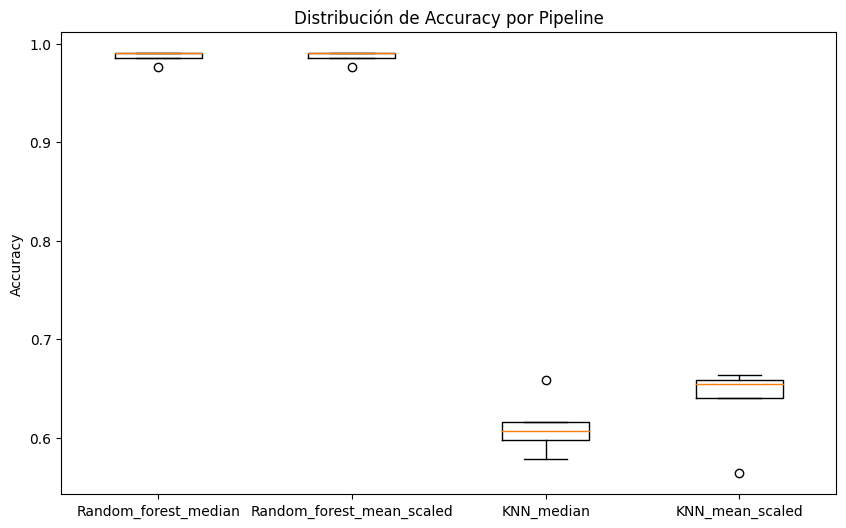

In [664]:
import matplotlib.pyplot as plt

# 1. Extraemos los nombres de los pipelines
pipelines = df_cv_score_results['pipeline'].unique()

# 2. Creamos una lista donde cada elemento son los resultados de un pipeline
# Esto es lo que Matplotlib necesita: una lista de listas/series
data_to_plot = [df_cv_score_results[df_cv_score_results['pipeline'] == p]['accuracy'] for p in pipelines]

# 3. Graficamos usando 'data_to_plot' y pasamos los nombres en 'labels'
plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=pipelines)

plt.title('Distribución de Accuracy por Pipeline')
plt.ylabel('Accuracy')
plt.show()

In [665]:
from sklearn.model_selection import GridSearchCV

In [666]:
pipeline_rf_mean_scaled = Pipeline(steps=[
    ('preprocessor', preprocessor_mean),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [667]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200], # número de árboles
    'classifier__max_depth': [None, 10, 20], # profundidad máxima de los árboles
    'classifier__min_samples_split': [2, 5, 10] # número mínimo de muestras para dividir un nodo
}

In [668]:
grid_search = GridSearchCV(
    estimator=pipeline_rf_mean_scaled,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1, # Usar todos los núcleos disponibles
)

In [669]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'heart_rate',
                                                                          'systolic_bp',
                                                                          'diastolic_bp',
                                                                          'blood_sugar',
                                                                          'ckmb',
                                                                          'troponin']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [670]:
grid_search.best_params_

{'classifier__max_depth': None,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 50}

In [671]:
grid_search.best_score_

0.9876819407008087

In [672]:
import joblib

best_model = grid_search.best_estimator_

print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'heart_rate',
                                                   'systolic_bp',
                                                   'diastolic_bp',
                                                   'blood_sugar', 'ckmb',
                                                   'troponin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequen

In [673]:
DATA_DIR = Path.cwd().resolve().parent / "modelos"

joblib.dump(best_model, DATA_DIR / "randomForest_best_model.joblib")

['C:\\Users\\usuario\\Desktop\\za-proyecto-I\\src\\modelos\\randomForest_best_model.joblib']

# Modelo con datos no vistos

In [674]:
loaded_model = joblib.load(DATA_DIR / "randomForest_best_model.joblib")

In [675]:
type(loaded_model)

sklearn.pipeline.Pipeline

In [676]:
np.random.seed(42)

n_samples = 80

df_data_test = pd.DataFrame({
    'age':np.random.uniform(14,103, size=n_samples),
    'gender':np.random.choice([0,1], size=n_samples),
    'heart_rate':np.random.uniform(20,1111, size=n_samples),
    'systolic_bp':np.random.uniform(42,223, size=n_samples),
    'diastolic_bp':np.random.uniform(38,154, size=n_samples),
    'blood_sugar':np.random.uniform(35,541, size=n_samples),
    'ckmb':np.random.uniform(0.3,300, size=n_samples),
    'troponin':np.random.uniform(0.00,10.3, size=n_samples)
})

df_data_test.head()

,age,gender,heart_rate,systolic_bp,diastolic_bp,blood_sugar,ckmb,troponin
0,47.334071,0,900.917209,158.207728,141.240620,231.413983,25.725863,6.119546
1,98.613573,0,997.635608,57.229334,77.207438,360.503839,295.995882,3.923176
2,79.147461,1,366.941791,71.254797,81.567623,266.875963,112.468957,9.990118
3,67.280605,1,140.066650,204.638308,48.901905,311.082095,111.381451,8.673825
4,27.885659,1,268.677262,151.763660,105.080496,511.381193,243.896030,8.634786


In [677]:
y_pred_sintetic = loaded_model.predict(df_data_test)

In [678]:
y_pred_sintetic

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [679]:
df_predictions = df_data_test.copy()

df_predictions['result'] = y_pred_sintetic

df_predictions

,age,gender,heart_rate,systolic_bp,diastolic_bp,blood_sugar,ckmb,troponin,result
0,47.334071,0,900.917209,158.207728,141.240620,231.413983,25.725863,6.119546,True
1,98.613573,0,997.635608,57.229334,77.207438,360.503839,295.995882,3.923176,True
2,79.147461,1,366.941791,71.254797,81.567623,266.875963,112.468957,9.990118,True
3,67.280605,1,140.066650,204.638308,48.901905,311.082095,111.381451,8.673825,True
4,27.885659,1,268.677262,151.763660,105.080496,511.381193,243.896030,8.634786,True
...,...,...,...,...,...,...,...,...,...
75,78.881638,1,400.987646,132.774449,112.520636,389.690381,8.202182,4.881805,True
76,82.643061,1,812.017646,186.491427,41.075312,71.818081,113.126071,6.875845,True
77,20.589974,1,998.747294,159.643471,105.949967,450.861190,243.222833,1.774895,True
78,45.903450,0,987.811289,169.056005,147.066708,392.358567,296.186656,1.980577,True
